In [1]:
from datetime import datetime
import time
from IPython import get_ipython

ip = get_ipython()
_start_time = None

# Before cell runs
def pre_run_cell(info):
    global _start_time
    _start_time = time.time()

# After cell runs
def post_run_cell(result):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    duration = time.time() - _start_time if _start_time else 0
    print(f"Cell Duration: {duration:.2f} sec")

ip.events.register('pre_run_cell', pre_run_cell)
ip.events.register('post_run_cell', post_run_cell)

Cell Duration: 0.00 sec


In [2]:
%load_ext autoreload
%autoreload 2

Cell Duration: 0.01 sec


In [6]:
# load the data
from utils_conversational import PROCESSED_DATA_FOLDER
import pickle
# ignore the pre-computed score function values
with open(PROCESSED_DATA_FOLDER / 'ClariQ_cali.pkl', 'rb') as f:
    (
        x_cali,
        y_cali,
        a_cali
    ) = pickle.load(f)
with open(PROCESSED_DATA_FOLDER / 'ClariQ_test.pkl', 'rb') as f:
    (
        x_test,
        y_test,
        a_test
    ) = pickle.load(f)

Cell Duration: 0.02 sec


In [4]:
# prepare score function
from functools import partial
from LLMs import LLM_Score
llm_score = LLM_Score()
# do not return rationales during conformal generation
# only return a single scalar score
my_score_fn = partial(llm_score.score, verbose=False)

# initialize sequence selector
# Note: here the RunningMaxSequenceSelector is equivalent to the 
#       RunningMaxSingleSequenceSelector. We adopt the former since
#       it directly returns the number of clarifications, which is 
#       used to compute the admissibility (i.e. how many clarifications are asked).
from conformal_generation import sequence_selector
seq_selector = sequence_selector.RunningMaxSequenceSelector(
                    my_score_fn
                )

Initialized scoring LLM using gpt-4o!
Cell Duration: 0.68 sec


In [5]:
# cast the calibration dataset into the dataset in the package
from conformal_generation import calibration_dataset

ds_cali = calibration_dataset.IndividualScoreCalibrationDataset(
                    sequence_selector=seq_selector,
                    input_dataset=x_cali,
                    raw_generated_dataset=y_cali,
                    admissibility_dataset=a_cali,
                    admissibility_aggregation=max,
                    admissibility_function_lower_bound=0,
                    iterate_inputs=True
            )

# initialize the conformal generator
from conformal_generation import conformal_generation
cg = conformal_generation.ConformalGeneration(
            sequence_selector=seq_selector,
            calibration_dataset=ds_cali
        )

Cell Duration: 0.01 sec


In [13]:
import numpy as np
import math
from tqdm import tqdm
from conformal_generation.utils import plot_admissibility_curve, plot_generation_sequence_length

GAMMA_VALUE_LIST = np.arange(0.05, 1.0, 0.05)

def evaluate_conformal_generation(cg, x_all, y_all, a_all, ds_name):
    admissibility_results = {gamma: -1 for gamma in GAMMA_VALUE_LIST}
    is_lambda_inf = {gamma: False for gamma in GAMMA_VALUE_LIST}
    (averge_n_questions_conformal, 
        std_n_questions_conformal) = ({gamma: -1 for gamma in GAMMA_VALUE_LIST}, 
                                        {gamma: -1 for gamma in GAMMA_VALUE_LIST})  

    for gamma_value in tqdm(GAMMA_VALUE_LIST, desc="Iterating Gamma values"):
        print(f"{ds_name} Set: calibrating for gamma = {gamma_value}...")
        cg.calibrate(gamma=gamma_value, recalibrate=True) 
        if cg._conformal_threshold == math.inf:
            print(f"[Note] lambda_hat is infinity for gamma = {gamma_value}.")
            is_lambda_inf[gamma_value] = True
            admissibility_results[gamma_value] = 1.0
            averge_n_questions_conformal[gamma_value] = np.mean([len(a) for a in a_all])
            std_n_questions_conformal[gamma_value] = np.std([len(a) for a in a_all])
            continue

        # generate
        conformal_holds_all = []
        n_questions_conformal_all = []
        for x, y, a in tqdm(zip(x_all, y_all, a_all), 
                            desc=f"Generating on the dataset (gamma={gamma_value:.1f})", 
                            total=len(x_test)):
            y_selected = cg.select(x, 
                                   y,
                                   iterate_inputs=True)
            # see if the conformal guarantee is satisfied
            n_questions_conformal = len(y_selected)
            n_questions_gt = len(a)
            n_questions_conformal_all.append(n_questions_conformal)
            conformal_holds_all.append(int(n_questions_conformal >= n_questions_gt))
        
        admissibility_results[gamma_value] = np.mean(conformal_holds_all)
        averge_n_questions_conformal[gamma_value] = np.mean(n_questions_conformal_all)
        std_n_questions_conformal[gamma_value] = np.std(n_questions_conformal_all)
    return admissibility_results, is_lambda_inf, averge_n_questions_conformal, std_n_questions_conformal


Cell Duration: 0.01 sec


### Test Set Evaluation

In [7]:
(
    admissibility_results_test,
    is_lambda_inf_test, 
    averge_n_questions_conformal_test,
    std_n_questions_conformal_test
) = evaluate_conformal_generation(
        cg, x_test, y_test, a_test, ds_name="Test"
    )

Iterating Gamma values:   0%|          | 0/19 [00:00<?, ?it/s]

Test Set: calibrating for gamma = 0.05...


Iterating Gamma values:   5%|▌         | 1/19 [13:20<4:00:11, 800.65s/it]

Test Set: calibrating for gamma = 0.1...


Iterating Gamma values:  11%|█         | 2/19 [16:59<2:09:51, 458.33s/it]

...

Test Set: calibrating for gamma = 0.8...


Iterating Gamma values:  84%|████████▍ | 16/19 [1:51:44<25:59, 519.94s/it]

Test Set: calibrating for gamma = 0.8500000000000001...


Iterating Gamma values: 100%|██████████| 19/19 [2:00:52<00:00, 381.71s/it]

Test Set: calibrating for gamma = 0.9000000000000001...
[Note] lambda_hat is infinity for gamma = 0.9000000000000001.
Test Set: calibrating for gamma = 0.9500000000000001...
[Note] lambda_hat is infinity for gamma = 0.9500000000000001.
Cell Duration: 7252.53 sec


In [8]:
# save results
import pickle

if "admissibility_results_test" in locals():
    with open("conformal_results/conversational_AI_conformal_generation_results.pkl",
            'wb') as f:
        pickle.dump((
            admissibility_results_test,
            is_lambda_inf_test, 
            averge_n_questions_conformal_test,
            std_n_questions_conformal_test
        ), f)

Cell Duration: 0.02 sec


In [5]:
# load results
import pickle

with open("conformal_results/conversational_AI_conformal_generation_results.pkl",
            'rb') as f:
        (
            admissibility_results_test,
            is_lambda_inf_test, 
            averge_n_questions_conformal_test,
            std_n_questions_conformal_test
        ) = pickle.load(f)

Cell Duration: 0.01 sec


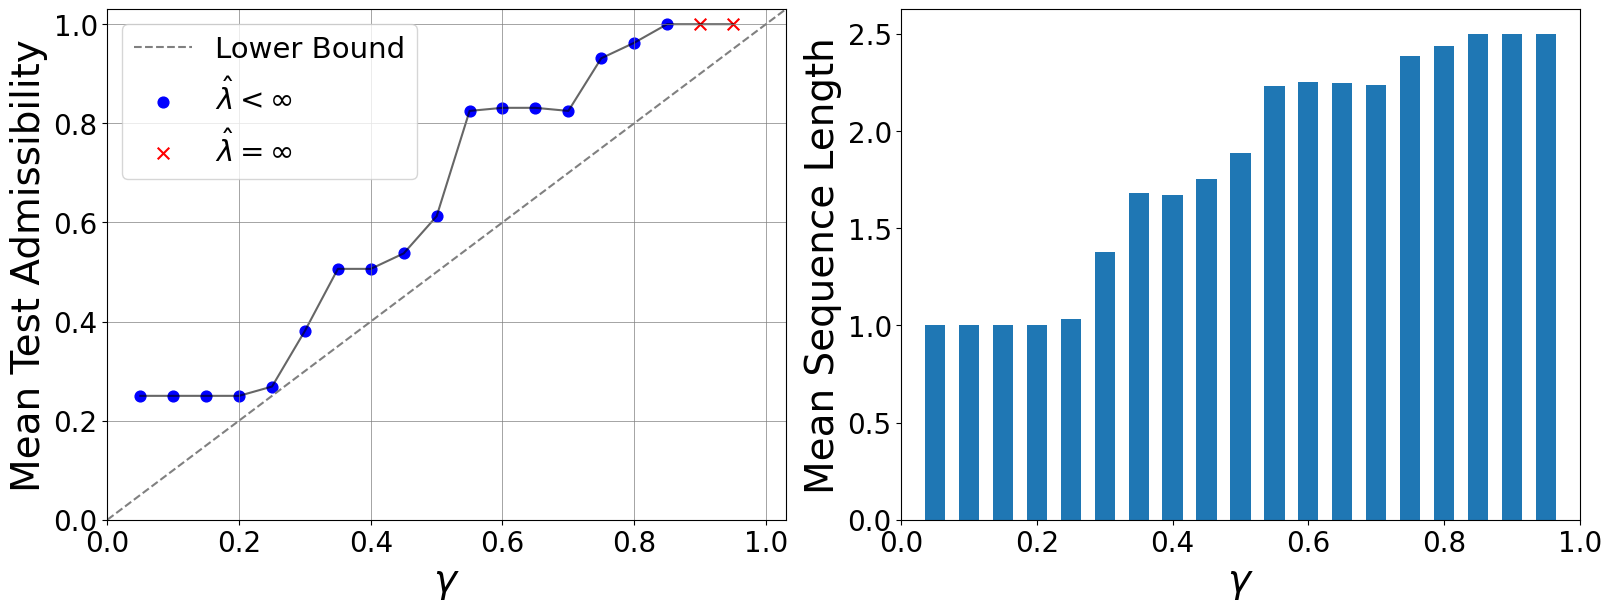

Cell Duration: 0.59 sec


In [14]:
import matplotlib.pyplot as plt 

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,6), constrained_layout=True)

ax1 = plot_admissibility_curve(ax1,
                               admissibility_results=admissibility_results_test, 
                               is_lambda_inf=is_lambda_inf_test)

ax2 = plot_generation_sequence_length(ax2,
                                      averge_n_questions_conformal_test 
                                      )

plt.savefig("conversational_results.pdf")
plt.show()